In [2]:
# Data Preperation
import pandas as pd

df = pd.read_csv('D:/Final Project/Data/news.tsv',sep='\t')
df.head()

,News ID,Category,Topic,Headline,News body,Title entity,Entity content
0,N10000,sports,soccer,Predicting Atlanta United's lineup against Col...,"Only FIVE internationals allowed, count em, FI...","{""Atlanta United's"": 'Atlanta United FC'}","{'Atlanta United FC': {'type': 'item', 'id': '..."
1,N10001,news,newspolitics,Mitch McConnell: DC statehood push is 'full bo...,WASHINGTON -- Senate Majority Leader Mitch McC...,"{'DC': 'Washington, D.C.'}","{'Washington, D.C.': {'type': 'item', 'id': 'Q..."
2,N10002,news,newsus,Home In North Highlands Damaged By Fire,NORTH HIGHLANDS (CBS13) Fire damaged a home ...,{},{}
3,N10003,news,newspolitics,Meghan McCain blames 'liberal media' and 'thir...,Meghan McCain is speaking out after a journali...,{},{}
4,N10004,news,newsworld,Today in History: Aug 1,"1714: George I becomes King Georg Ludwig, Elec...",{},{}


In [4]:
df['Category'].value_counts()

Category
sports           30557
news             26689
finance          10571
lifestyle         7405
autos             5494
travel            5381
foodanddrink      5286
video             4968
tv                3981
health            3799
weather           3298
music             2547
movies            1996
entertainment     1487
kids               299
europe               2
northamerica         1
adexperience         1
Name: count, dtype: int64

In [5]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
# Data Cleaniing and Preprocessing including Stopword Removal

import re
import string
import pandas as pd
from nltk.corpus import stopwords
import nltk

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):

    if not isinstance(text,str): 
        return ""
    
    text =  re.sub(r"<.*?>"," ",text)

    text = re.sub(r"http\S+|www\S+|https\S+"," ",text)

    text = re.sub(
        "[" 
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+", 
        "", 
        text
    )

    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", " ", text)

    allowed = set(string.ascii_letters + string.digits + " .,!?")
    text = "".join(ch for ch in text if ch in allowed)

    text = text.lower()

    text = " ".join(text.split())

    tokens = [
        word for word in text.split()
        if word not in STOPWORDS
    ]
    
    text = " ".join(tokens)

    return text

In [7]:
df["text"] = df["Headline"].fillna("") + " " + df["News body"].fillna("")
df = df.rename(columns={"Category": "label"}).dropna()

df["clean_text"] = df["text"].apply(clean_text)

In [8]:
df.tail()

,News ID,label,Topic,Headline,News body,Title entity,Entity content,text,clean_text
113757,N123757,sports,soccer_fifa_wwc,Hope who? Alyssa Naeher's penalty save sends U...,"LYON, France At the conclusion of the United...","{'USWNT': ""United States women's national socc...","{""United States women's national soccer team"":...",Hope who? Alyssa Naeher's penalty save sends U...,hope who? alyssa naeher penalty save sends usw...
113758,N123758,sports,baseball_mlb,Chris Sale Explains What Specifically Has Gone...,The first half of Chris Sale's season could be...,{},{},Chris Sale Explains What Specifically Has Gone...,chris sale explains specifically gone wrong fi...
113759,N123759,sports,basketball_nba_videos,Raptor fans jam streets to celebrate 1st NBA t...,Canadians are celebrating the country's first ...,{'NBA': 'National Basketball Association'},{'National Basketball Association': {'type': '...,Raptor fans jam streets to celebrate 1st NBA t...,raptor fans jam streets celebrate 1st nba titl...
113760,N123760,news,newspolitics,Judge won't allow Flynn to fire his attorneys,A federal judge denied the request by Michael ...,{'Flynn': 'Michael Flynn'},"{'Michael Flynn': {'type': 'item', 'id': 'Q683...",Judge won't allow Flynn to fire his attorneys ...,judge allow flynn fire attorneys federal judge...
113761,N123761,sports,football_nfl,Worley thinks he and Conley will rival greates...,Confidence imparts a wonderful inspiration on ...,{'Conley': 'Mike Conley Jr.'},"{'Mike Conley Jr.': {'type': 'item', 'id': 'Q9...",Worley thinks he and Conley will rival greates...,worley thinks conley rival greatest raiders cb...


In [9]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
import joblib
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])

EDA

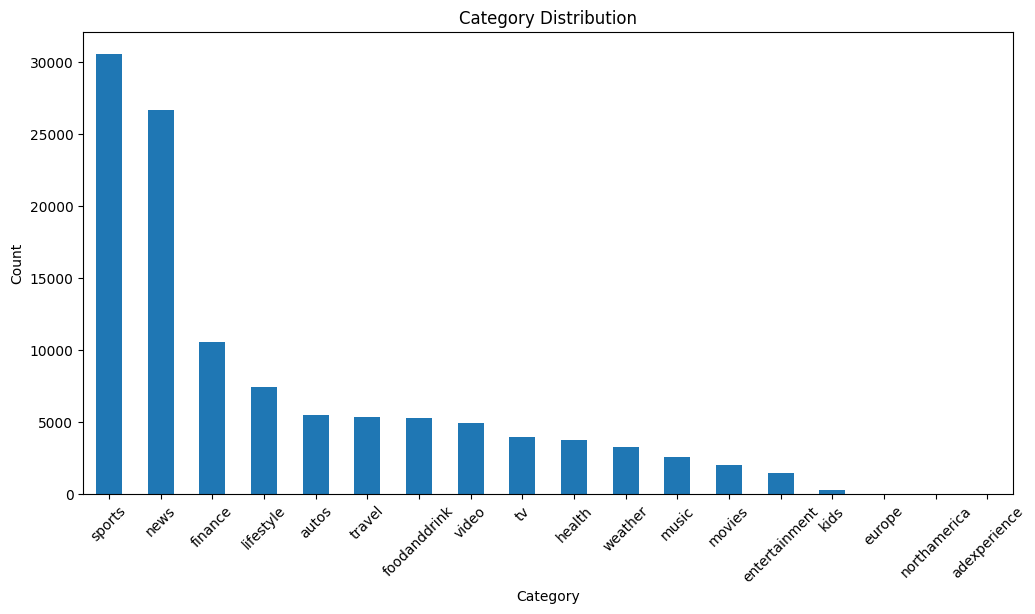

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
df["label"].value_counts().plot(kind="bar")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

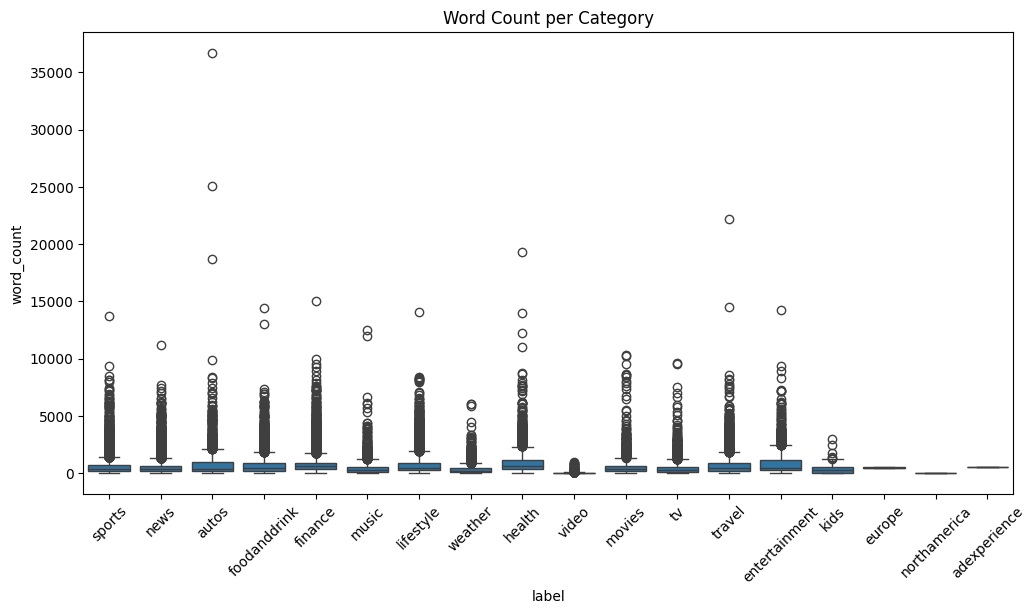

In [14]:
import seaborn as sns
def word_count(text):
    return len(text.split())

df["word_count"] = df["text"].apply(word_count)

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="label", y="word_count")
plt.xticks(rotation=45)
plt.title("Word Count per Category")
plt.show()

Models

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import joblib

In [16]:
df = df[["text", "label"]]
df["label_encoded"] = le.fit_transform(df["label"])
df

,text,label,label_encoded
0,Predicting Atlanta United's lineup against Col...,sports,13
1,Mitch McConnell: DC statehood push is 'full bo...,news,11
2,Home In North Highlands Damaged By Fire NORTH ...,news,11
3,Meghan McCain blames 'liberal media' and 'thir...,news,11
4,Today in History: Aug 1 1714: George I becomes...,news,11
...,...,...,...
113757,Hope who? Alyssa Naeher's penalty save sends U...,sports,13
113758,Chris Sale Explains What Specifically Has Gone...,sports,13
113759,Raptor fans jam streets to celebrate 1st NBA t...,sports,13
113760,Judge won't allow Flynn to fire his attorneys ...,news,11


In [17]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label_encoded"],
    test_size=0.2,
    random_state=42
)

In [18]:
# Four Models 

pipelines = {
    "LR_TFIDF": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")),
        ("clf", LogisticRegression(max_iter=5000))
    ]),

    "LR_BOW": Pipeline([
        ("bow", CountVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")),
        ("clf", LogisticRegression(max_iter=5000))
    ]),

    "SVM_TFIDF": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")),
        ("clf", LinearSVC())
    ]),

    "SVM_BOW": Pipeline([
        ("bow", CountVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english")),
        ("clf", LinearSVC())
    ]),
}

In [20]:
# Evaluate Models
def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds, average="weighted", zero_division=0))
    print("Recall:", recall_score(y_test, preds, average="weighted", zero_division=0))
    print("F1 Score:", f1_score(y_test, preds, average="weighted", zero_division=0))
    print("\nClassification Report:\n", classification_report(y_test, preds, zero_division=0))

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Weighted F1": f1_score(y_test, preds, average="weighted")
    }

In [21]:
all_results = []

for name, pipe in pipelines.items():
    result = evaluate_model(name, pipe)
    all_results.append(result)

results_df = pd.DataFrame(all_results)
print("\nFINAL MODEL COMPARISON")
print(results_df)


LR_TFIDF
Accuracy: 0.7810562420298139
Precision: 0.7810559453086995
Recall: 0.7810562420298139
F1 Score: 0.778427389726029

Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.82      0.84      1109
           2       0.72      0.37      0.49       310
           3       0.00      0.00      0.00         1
           4       0.83      0.79      0.81      2070
           5       0.85      0.81      0.83      1034
           6       0.83      0.74      0.78       744
           7       0.00      0.00      0.00        53
           8       0.66      0.65      0.66      1489
           9       0.73      0.65      0.69       415
          10       0.75      0.61      0.67       504
          11       0.70      0.81      0.75      5356
          13       0.94      0.95      0.95      6083
          14       0.69      0.56      0.62      1113
          15       0.67      0.60      0.63       837
          16       0.45      0.47      0

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



SVM_BOW
Accuracy: 0.7383580317488238
Precision: 0.7432515006221178
Recall: 0.7383580317488238
F1 Score: 0.7392217852092074

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.84      0.77      0.80      1109
           2       0.50      0.40      0.44       310
           3       0.00      0.00      0.00         1
           4       0.81      0.75      0.78      2070
           5       0.72      0.75      0.74      1034
           6       0.71      0.74      0.72       744
           7       0.06      0.08      0.07        53
           8       0.64      0.54      0.59      1489
           9       0.62      0.59      0.60       415
          10       0.62      0.60      0.61       504
          11       0.70      0.73      0.72      5356
          12       0.00      0.00      0.00         0
          13       0.92      0.94      0.93      6083
          14       0.63      0.51      0

In [22]:
best_model_name = results_df.sort_values("Weighted F1", ascending=False).iloc[0]["Model"]
print("\nBest Model:", best_model_name)


Best Model: LR_TFIDF


In [23]:
best_model = pipelines[best_model_name]
best_model.fit(X_train, y_train)

joblib.dump(best_model, "D:/Final Project/Classify/artifacts/ML/classify_ML_model.pkl")
print("Model saved")

Model saved


In [24]:
import pandas as pd
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, pipe in pipelines.items():
    preds = pipe.predict(X_test)

    results.append({
        "model_name": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, average="weighted", zero_division=0),
        "recall": recall_score(y_test, preds, average="weighted", zero_division=0),
        "f1": f1_score(y_test, preds, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results)

csv_path = "D:/Final Project/Classify/artifacts/model_comparisons.csv"

if os.path.exists(csv_path):
    results_df.to_csv(csv_path, mode="a", index=False, header=False)
else:
    results_df.to_csv(csv_path, index=False)

print("CSV saved")
results_df

CSV saved


,model_name,accuracy,precision,recall,f1
0,LR_TFIDF,0.781056,0.781056,0.781056,0.778427
1,LR_BOW,0.727101,0.729749,0.727101,0.727977
2,SVM_TFIDF,0.775296,0.771919,0.775296,0.772787
3,SVM_BOW,0.738358,0.743252,0.738358,0.739222
